In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while project_root.name != 'python' and project_root.parent != project_root:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

## Downloading the data

In [2]:
from data import download_tickers_history
from data.constants import TRADING_DAYS_PER_YEAR

# set the date range for the historic data
start_date = datetime(year=2020, month=1, day=1)
end_date = datetime(year=2026, month=1, day=1)
tickers = ['NVDA', 'AAPL', 'PLTR', 'DKNG', 'CAT', 'INTC', 'AMZN', 'TSLA', 'GOOG', 'MSFT']
history = download_tickers_history(start_date, end_date, tickers).dropna()

start_date = datetime(year=2020, month=1, day=1)
end_date = datetime(year=2026, month=1, day=1)
tickers = ['^GSPC']
sp500_history = download_tickers_history(start_date, end_date, tickers).dropna()

history.head()


Ticker       PLTR                                       DKNG             \
Price        Open   High   Low Close       Volume       Open       High   
Date                                                                      
2020-09-30  10.00  11.41  9.11  9.50  338584400.0  56.200001  59.119999   
2020-10-01   9.69  10.10  9.23  9.46  124297600.0  61.779999  62.730000   
2020-10-02   9.06   9.28  8.94  9.20   55018300.0  58.990002  64.190002   
2020-10-05   9.43   9.49  8.92  9.03   36316900.0  61.340000  62.450001   
2020-10-06   9.04  10.18  8.90  9.90   90864000.0  59.950001  60.360001   

Ticker                                      ...        MSFT              \
Price             Low      Close    Volume  ...        Open        High   
Date                                        ...                           
2020-09-30  55.799999  58.840000  19002800  ...  197.551394  201.593148   
2020-10-01  59.820000  61.830002  24122700  ...  203.029213  203.504713   
2020-10-02  58.849998  63.779999  20483900  ...  197.808208  200.651707   
2020-10-05  58.599998  60.549999  34511900  ...  197.066443  200.100138   
2020-10-06  55.799999  56.779999  27202700  ...  198.588019  199.881366   

Ticker                                             INTC                        \
Price              Low       Close    Volume       Open       High        Low   
Date                                                                            
2020-09-30  196.419701  200.024002  33829100  45.987766  47.010913  45.906991   
2020-10-01  200.965542  202.049683  27158400  47.028861  47.316060  46.660887   
2020-10-02  195.468739  196.086899  33154800  46.221109  46.651907  45.763387   
2020-10-05  196.838197  200.071609  21331600  46.041616  46.499342  46.014692   
2020-10-06  194.784015  195.820602  28554300  46.409584  47.298108  45.978786   

Ticker                           
Price           Close    Volume  
Date                             
2020-09-30  46.472412  27711300  
2020-10-01  46.885262  22127600  
2020-10-02  45.781334  25811800  
2020-10-05  46.391640  20883200  
2020-10-06  46.104435  25642800  

[5 rows x 50 columns]

## Backtesting logic
Backtesting of a portfolio strategy is a historical simulation of the workings of a placeholder in time to test how the weight distribution would have performed on real out-of-sample data.

The portfolio cannot be optimized once across the entire story - this would create a critical look-ahead bias.
Instead, the simulation moves over time step by step:

1. **Time $t$ (Rebalancing Date)**: we take a line from the history strictly to $t$ (for example, last 504 trading days).
2. **Parameter evaluation**: we calculate the cost of $\Sigma_{t+1}$ via GARCH/EGARCH or Ledoit-Wolf. We estimate the expected returns of $\mu_{t+1}$ via Black-Litterman.
3. **Optimization**: find the optimal vector for $w_t *$ target weights (Max Sharpe, Min Volatility, etc.).
4. **Out-of-Sample execution**: "freeze" weights $w_t *$ and apply them to real price movements from the moment of $t$ until the next rebalancing date of $t +  Delta t$ (for example, on the 21st trading day).
5. **Window shift**: go to $t + \Delta t$ and repeat the procedure.

#### What to take into account for correct basket
To reflect real trade, the basket has four key components:
* **Frequency of rebalancing ($\Delta t$)**
    * Daily: too much trading; we will lose all in profit by commissions.
    * Monthly (~21 trading day): Standard for medium-term portfolio strategies.
* **Transaction costs & slippage**
    
    When changing weights from $w_{t-1}$ to $w_t$, the portfolio makes turnover (Turnover):
    $$\text{Turnover}_t = \sum_{i=1}^N \vert{}w_{i, t} - w_{i, t^-}\vert{},$$
    Each deal is covered by a broker’s commission and through capture (usually $0.05% - 0.1% of the deal’s value).
* **Weight drift**
    
    Between rebalancing days, asset prices change unevenly. The share of rising stocks naturally increases and falling shares decline within a holding period.
* **Benchmark for comparison**
    * Strategy results are necessarily overlaid on charts: **S&P 500 (^GSPC)** - passive market.
    * **$1/N$ (Equal-Weighted)** - naive diversification with similar frequency of rebalancing.

In [4]:
from src.backtest import perform_backtesting

lookback_window = 504
rebalancing_period = 21 # 21-trading day

portfolio_value = 10000.0 # starting capital = 10,000 $
broker_commission = 0.0005 # 0.05%

backtest_res_df = perform_backtesting(
    history,
    portfolio_value,
    'EGARCH_SORTINO',
    'HISTORICAL',
    sp500_history,
    lookback_window,
    rebalancing_period,
    broker_commission,
    'FIXED'
)

backtest_res_df.head()


,sharpe,sortino,weights,daily_return,equal_portfolio_daily_return,portfolio_value,equal_portfolio_value,sp500_value
date,,,,,,,,
2022-09-30,None,None,PLTR 0.1 DKNG 0.1 GOOG 0.1 AMZN 0....,-0.014776,-0.014776,9852.242031,9852.242031,10000.000000
2022-10-03,None,None,PLTR 0.1 DKNG 0.1 GOOG 0.1 AMZN 0....,0.018720,0.018720,10036.679724,10036.679724,10258.838950
2022-10-04,None,None,PLTR 0.1 DKNG 0.1 GOOG 0.1 AMZN 0....,0.041522,0.041522,10453.419060,10453.419060,10572.592209
2022-10-05,None,None,PLTR 0.1 DKNG 0.1 GOOG 0.1 AMZN 0....,-0.005066,-0.005066,10400.458597,10400.458597,10551.257260
2022-10-06,None,None,PLTR 0.1 DKNG 0.1 GOOG 0.1 AMZN 0....,-0.008705,-0.008705,10309.923723,10309.923723,10443.158776


## Visualize backtesting data

#### Cumulative Equity Curve
Shows whether a complex algorithmic platform overtakes the simple passive market and naive (equal-weighted) diversification at a distance.

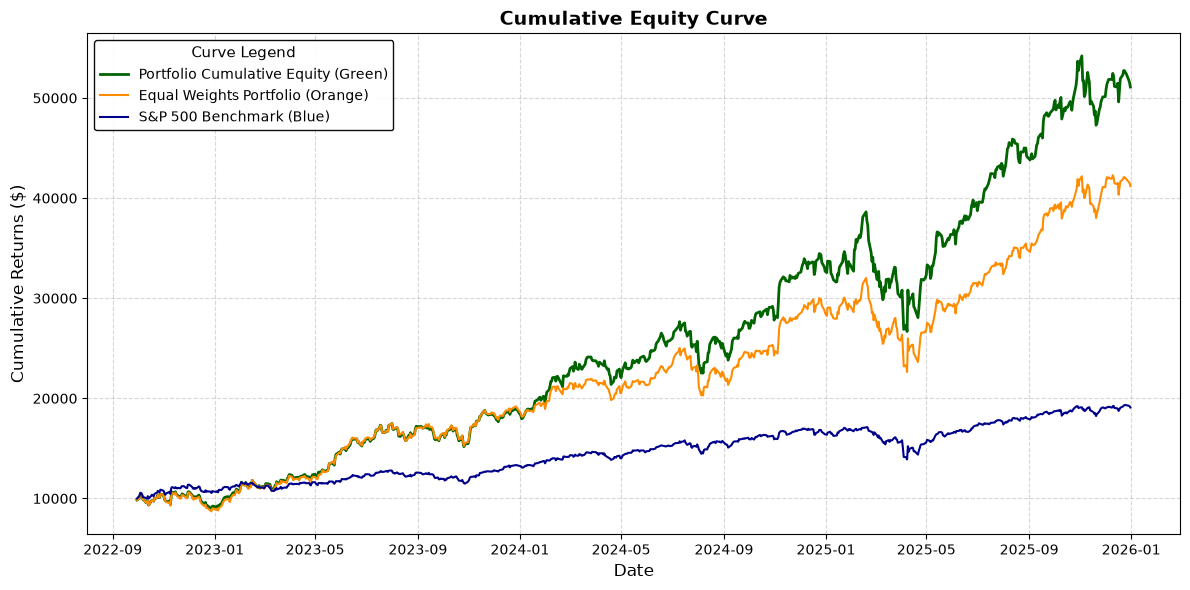

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

# Trader's portfolio
date = pd.to_datetime(backtest_res_df.index)
equity = backtest_res_df["portfolio_value"]

ax.plot(
    date,
    equity,
    color="darkgreen",
    linewidth=2,
    label="Portfolio Cumulative Equity (Green)",
)

# Equal weights
eq_equity = backtest_res_df["equal_portfolio_value"]

ax.plot(
    date,
    eq_equity,
    color="darkorange",
    linewidth=1.5,
    label="Equal Weights Portfolio (Orange)",
)

# S&P 500
sp500_equity = backtest_res_df["sp500_value"]

ax.plot(
    date,
    sp500_equity,
    color="darkblue",
    linewidth=1.5,
    label="S&P 500 Benchmark (Blue)",
)

# Title and labels
plt.title('Cumulative Equity Curve', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Returns ($)', fontsize=12)

# Legend box showing what each color curve represents
ax.legend(
    title="Curve Legend",
    title_fontsize=11,
    loc="upper left",
    frameon=True,
    facecolor="#ffffff",
    edgecolor="black",
    framealpha=0.95,
    fontsize=10,
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


#### Underwater Drawdown Chart
Shows strategy stress test. The optimized portfolio should have a significantly lower depth of flow and faster recovery (Recovery Time) than the _S&P 500_ during crises.

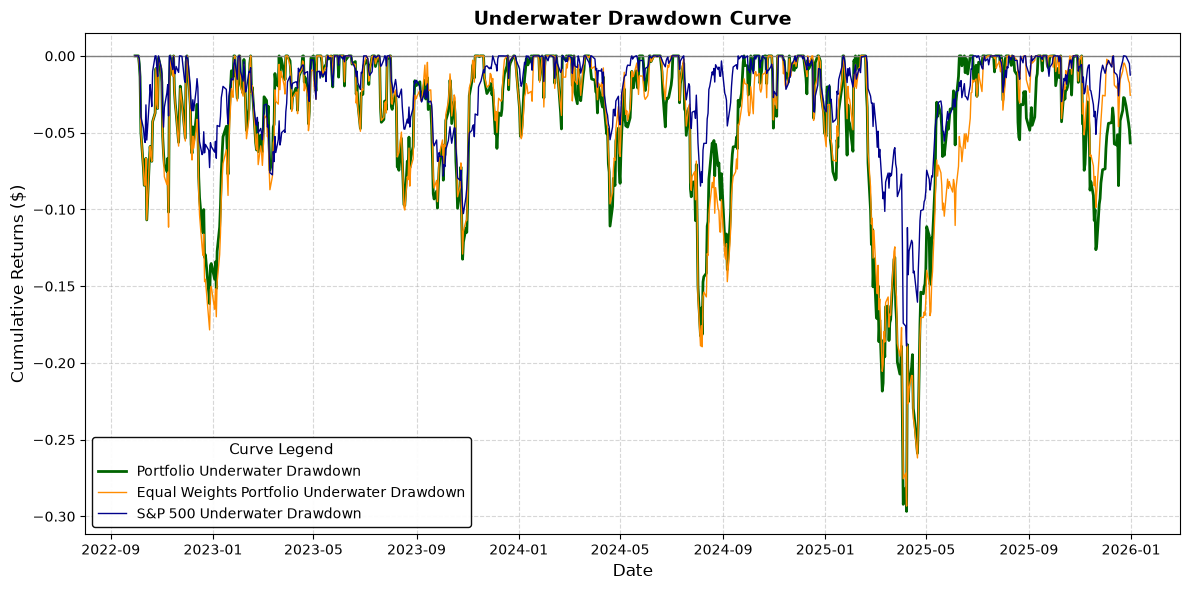

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

# Trader's portfolio
date = pd.to_datetime(backtest_res_df.index)
equity = backtest_res_df["portfolio_value"]
drawdown = (equity - equity.cummax()) / equity.cummax()

ax.plot(
    date,
    drawdown,
    color="darkgreen",
    linewidth=2,
    label="Portfolio Underwater Drawdown",
)

ax.axhline(0, color="gray", linestyle="-", linewidth=1, alpha=1)

# Equal weights portfolio
eq_equity = backtest_res_df["equal_portfolio_value"]
eq_drawdown = (eq_equity - eq_equity.cummax()) / eq_equity.cummax()

ax.plot(
    date,
    eq_drawdown,
    color="darkorange",
    linewidth=1,
    label="Equal Weights Portfolio Underwater Drawdown",
)

# S&P 500
sp500_drawdown = (sp500_equity - sp500_equity.cummax()) / sp500_equity.cummax()

ax.plot(
    date,
    sp500_drawdown,
    color="darkblue",
    linewidth=1,
    label="S&P 500 Underwater Drawdown",
)

# Title and labels
plt.title('Underwater Drawdown Curve', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Returns ($)', fontsize=12)

# Legend box showing what each color curve represents
ax.legend(
    title="Curve Legend",
    title_fontsize=11,
    loc="lower left",
    frameon=True,
    facecolor="#ffffff",
    edgecolor="black",
    framealpha=0.95,
    fontsize=10,
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


#### Weights History
Shows model stability and adequacy:
* If weights change smoothly from month to month, the model is stable.
* If the weights are chaotically raised from $0% to $100% each step - too much noise in the optimizer, transaction fees will eat up all the profits.

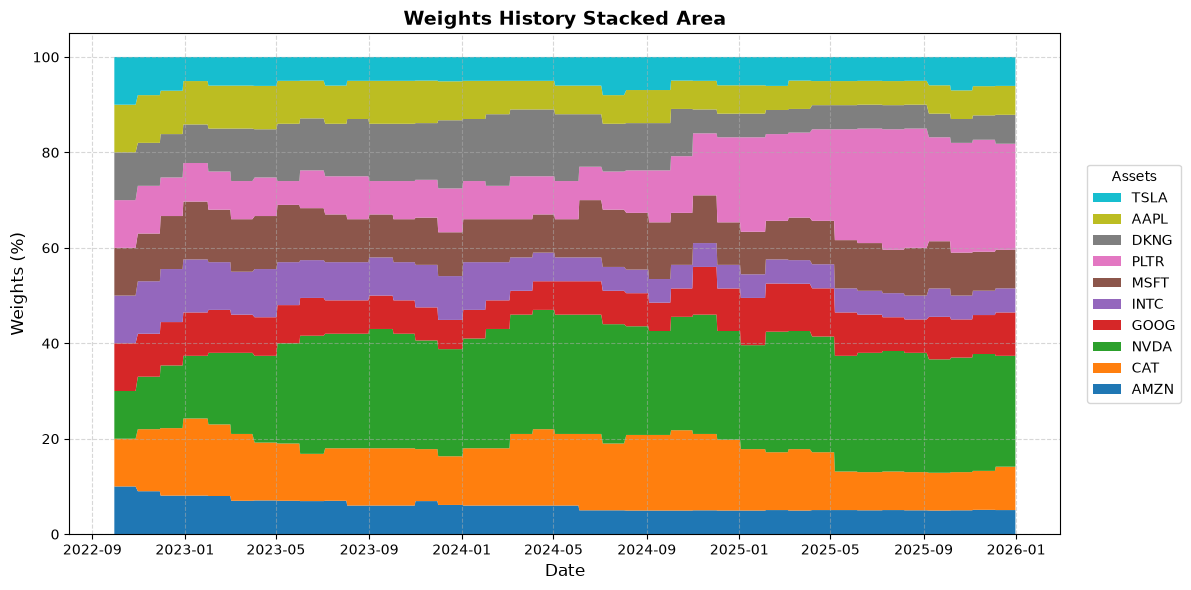

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

# Trader's portfolio
close = history.xs("Close", axis=1, level="Price")
weights_df = pd.DataFrame(
    (backtest_res_df["weights"] * 100).tolist(),
    index=backtest_res_df.index,
    columns=close.columns
)
date = weights_df.index
ax.stackplot(
    date,
    weights_df.T,
    linewidth=2,
    labels=weights_df.columns,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Assets",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.title('Weights History Stacked Area', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weights (%)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


#### Rolling Sharpe Ratio, 6M / 1Y
Shows the stability of alpha generation over time. Good strategy keeps Rolling Sharpe consistently above zero, without falling into deep downsides during adjustments.

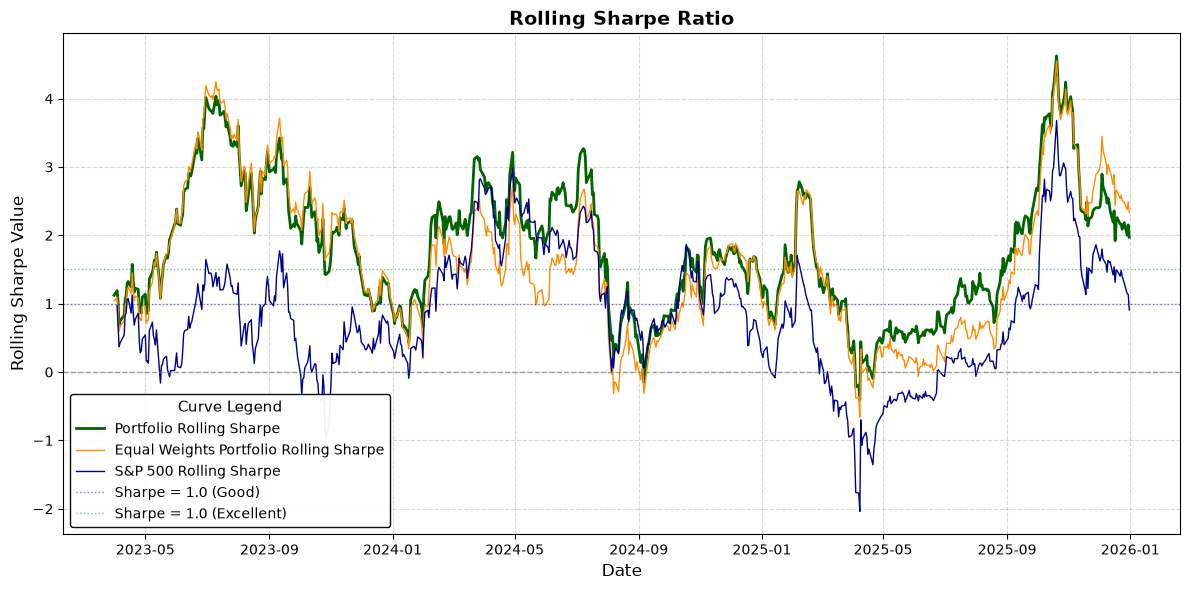

In [10]:
from src.backtest import calculate_rolling_sharpe

fig, ax = plt.subplots(figsize=(12, 6))

window = 126 # 126 days = 6 trading months
date = pd.to_datetime(backtest_res_df.index)

# Trader's portfolio
portfolio_ret = np.array(backtest_res_df["daily_return"])
portfolio_rolling_sharpe = calculate_rolling_sharpe(portfolio_ret, date[0], date[-1], window)

ax.plot(
    date,
    portfolio_rolling_sharpe,
    color="darkgreen",
    linewidth=2,
    label="Portfolio Rolling Sharpe",
)

# Equal weights portfolio
eq_portfolio_ret = np.array(backtest_res_df["equal_portfolio_daily_return"])
eq_rolling_sharpe = calculate_rolling_sharpe(eq_portfolio_ret, date[0], date[-1], window)

ax.plot(
    date,
    eq_rolling_sharpe,
    color="darkorange",
    linewidth=1,
    label="Equal Weights Portfolio Rolling Sharpe",
)

# S&P 500
out_of_sample_sp500_df = sp500_history[sp500_history.index.isin(date)]
sp500_close = out_of_sample_sp500_df.xs("Close", axis=1, level="Price")
sp500_ret = np.array(sp500_close / sp500_close.shift(1) - 1).flatten()
sp500_rolling_sharpe = calculate_rolling_sharpe(sp500_ret, date[0], date[-1], window)

ax.plot(
    date,
    sp500_rolling_sharpe,
    color="darkblue",
    linewidth=1,
    label="S&P 500 Rolling Sharpe",
)

ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(1.0, color="darkblue", linestyle=":", linewidth=1, alpha=0.5, label="Sharpe = 1.0 (Good)")
ax.axhline(1.5, color="green", linestyle=":", linewidth=1, alpha=0.5, label="Sharpe = 1.0 (Excellent)")

# Title and labels
plt.title('Rolling Sharpe Ratio', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rolling Sharpe Value', fontsize=12)

# Legend box showing what each color curve represents
ax.legend(
    title="Curve Legend",
    title_fontsize=11,
    loc="lower left",
    frameon=True,
    facecolor="#ffffff",
    edgecolor="black",
    framealpha=0.95,
    fontsize=10,
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


#### Rolling Sortino Ratio, 6M / 1Y
Shows the stability of alpha generation over time. Good strategy keeps Rolling Sortino consistently above zero, without falling into deep downsides during adjustments.

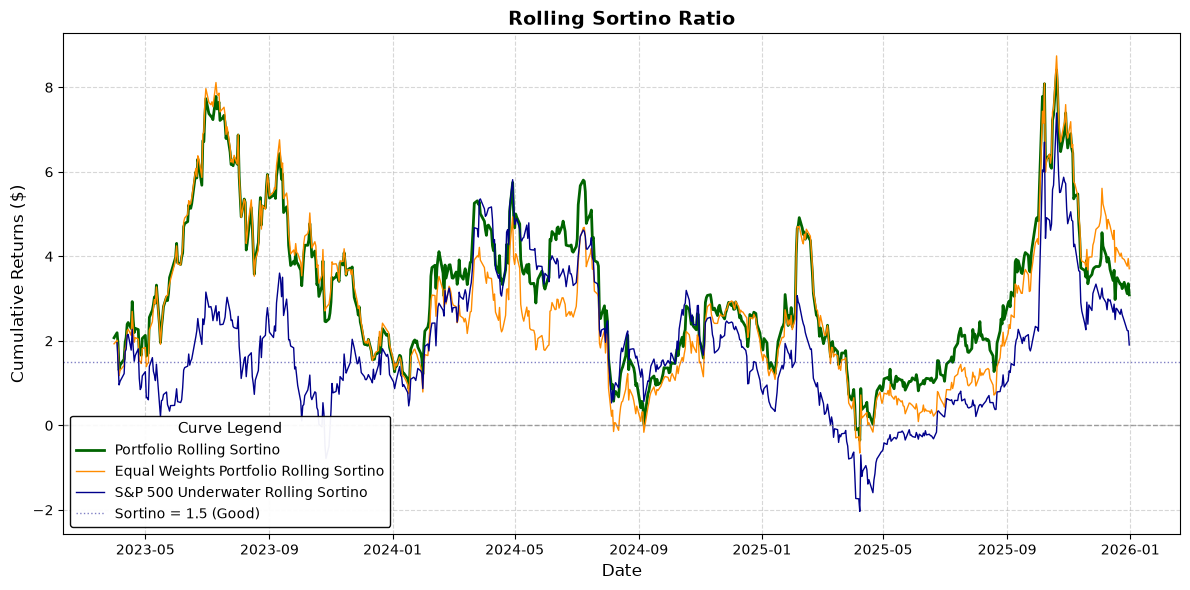

In [11]:
from src.backtest import calculate_rolling_sortino

fig, ax = plt.subplots(figsize=(12, 6))

window = 126 # 126 days = 6 trading months
date = pd.to_datetime(backtest_res_df.index)

# Trader's portfolio
portfolio_ret = np.array(backtest_res_df["daily_return"])
portfolio_rolling_sortino = calculate_rolling_sortino(portfolio_ret, date[0], date[-1], window)

ax.plot(
    date,
    portfolio_rolling_sortino,
    color="darkgreen",
    linewidth=2,
    label="Portfolio Rolling Sortino",
)

# Equal weights portfolio
eq_portfolio_ret = np.array(backtest_res_df["equal_portfolio_daily_return"])
eq_rolling_sortino = calculate_rolling_sortino(eq_portfolio_ret, date[0], date[-1], window)

ax.plot(
    date,
    eq_rolling_sortino,
    color="darkorange",
    linewidth=1,
    label="Equal Weights Portfolio Rolling Sortino",
)

# S&P 500
out_of_sample_sp500_df = sp500_history[sp500_history.index.isin(date)]
sp500_close = out_of_sample_sp500_df.xs("Close", axis=1, level="Price")
sp500_ret = np.array(sp500_close / sp500_close.shift(1) - 1).flatten()

sp500_rolling_sortino = calculate_rolling_sortino(sp500_ret, date[0], date[-1], window)

ax.plot(
    date,
    sp500_rolling_sortino,
    color="darkblue",
    linewidth=1,
    label="S&P 500 Underwater Rolling Sortino",
)

ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(1.5, color="darkblue", linestyle=":", linewidth=1, alpha=0.5, label="Sortino = 1.5 (Good)")

# Title and labels
plt.title('Rolling Sortino Ratio', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Returns ($)', fontsize=12)

# Legend box showing what each color curve represents
ax.legend(
    title="Curve Legend",
    title_fontsize=11,
    loc="lower left",
    frameon=True,
    facecolor="#ffffff",
    edgecolor="black",
    framealpha=0.95,
    fontsize=10,
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


## Metrics calculation

#### CAGR (Compound Annual Growth Rate)
Reflects the constant geometric rate of capital growth, smoothing out intermediate fluctuations. In contrast to average arithmetic annual returns, CAGR shows the real purchasing power of the final deposit: if the portfolio fell by 50% in the first year and rose by 50% in the second, the average is 0%, but CAGR is $-29.3 %$.

In [12]:
from src.backtest import calculate_cagr

testing_period = backtest_res_df.shape[0]

port_value = np.array(backtest_res_df["portfolio_value"])
port_cagr = calculate_cagr(port_value, testing_period)
print(f"Portfolio CAGR: {port_cagr:.2%}")

equal_value = np.array(backtest_res_df["equal_portfolio_value"])
equal_cagr = port_cagr = calculate_cagr(equal_value, testing_period)
print(f"Equal Weights Portfolio CAGR: {equal_cagr:.2%}")

sp500_equity = np.array(backtest_res_df["sp500_value"])
sp500_cagr = calculate_cagr(sp500_equity, testing_period)
print(f"S&P 500 CAGR: {sp500_cagr:.2%}")


Portfolio CAGR: 65.84%
Equal Weights Portfolio CAGR: 55.65%
S&P 500 CAGR: 22.13%


#### MDD (Max Drawdown)
A key measure of tail stress risk. Considered as a cumulative series of capital:
$$\text{Drawdown}_t = \frac{V_t - \max_{\tau \le t} V_\tau}{\max_{\tau \le t} V_\tau}, \quad \text{MDD} = \min_t (\text{Drawdown}_t)$$
Shows the psychological and marginal limit of the fund’s survival: a $50\%$ gap requires a $100\%$ net return just to return to unprofitability.

The good result is up to $15 - 20\%$.

In [13]:
from src.backtest import calculate_mdd

port_equity = np.array(backtest_res_df["portfolio_value"])
port_mdd = calculate_mdd(port_equity)
print(f"Portfolio MDD: {port_mdd:.2%}")

equal_equity = np.array(backtest_res_df["equal_portfolio_value"])
equal_mdd = port_mdd = calculate_mdd(equal_equity)
print(f"Equals Portfolio MDD: {equal_mdd:.2%}")

sp500_equity = np.array(backtest_res_df["sp500_value"])
sp500_mdd = calculate_mdd(sp500_equity)
print(f"S&N 500 MDD: {sp500_mdd:.2%}")


Portfolio MDD: 29.68%
Equals Portfolio MDD: 29.33%
S&N 500 MDD: 18.90%


#### Sharpe Ratio
Portfolio Aggregate Risk Premium. $> 1.0$ (good), $> 1.5$ (excellent)

In [14]:
from src.backtest import calculate_sharpe

date = pd.to_datetime(backtest_res_df.index)

port_ret = np.array(backtest_res_df["daily_return"])
port_sharpe = calculate_sharpe(port_ret, date[0], date[-1])
print(f"Portfolio Sharpe Ratio: {port_sharpe:.3}")

equal_ret = np.array(backtest_res_df["equal_portfolio_daily_return"])
equal_sharpe = calculate_sharpe(equal_ret, date[0], date[-1])
print(f"Equal Portfolio Sharpe Ratio: {equal_sharpe:.3}")

date = pd.to_datetime(backtest_res_df.index)
out_of_sample_sp500_df = sp500_history[sp500_history.index.isin(date)]
sp500_close = out_of_sample_sp500_df.xs("Close", axis=1, level="Price")
sp500_ret = (sp500_close / sp500_close.shift(1) - 1).dropna().values.flatten()
sp500_sharpe = calculate_sharpe(sp500_ret, date[0], date[-1])
print(f"S&P 500 Sharpe Ratio: {sp500_sharpe:.3}")


Portfolio Sharpe Ratio: 1.64
Equal Portfolio Sharpe Ratio: 1.5
S&P 500 Sharpe Ratio: 1.03


#### Sortino Ratio
Downside risk (loss) premium only. $> 1.5$ (higher than Sharpe in right-sided asymmetries)

In [15]:
from src.backtest import calculate_sortino

date = pd.to_datetime(backtest_res_df.index)

port_ret = np.array(backtest_res_df["daily_return"])
port_sortino = calculate_sortino(port_ret, date[0], date[-1])
print(f"Portfolio Sortino Ratio: {port_sortino:.3}")

equal_ret =  np.array(backtest_res_df["equal_portfolio_daily_return"])
equal_sortino = calculate_sortino(equal_ret, date[0], date[-1])
print(f"Equal Portfolio Sortino Ratio: {equal_sortino:.3}")


out_of_sample_sp500_df = sp500_history[sp500_history.index.isin(date)]
sp500_close = out_of_sample_sp500_df.xs("Close", axis=1, level="Price")
sp500_ret = (sp500_close / sp500_close.shift(1) - 1).dropna().values.flatten()
sp500_sortino = calculate_sortino(sp500_ret, date[0], date[-1])
print(f"S&P 500 Sortino Ratio: {sp500_sortino:.3}")


Portfolio Sortino Ratio: 2.52
Equal Portfolio Sortino Ratio: 2.3
S&P 500 Sortino Ratio: 1.54


#### Calmar Ratio
Return per unit of tail risk. If Sharpe evaluates the daily comfort of holding positions, Calmar checks whether the average annual profit pays for the maximum stress experienced. $> 1.0$ (acceptable), $> 2.0$ (high resistance).

In [16]:
from src.backtest import calculate_calmar

port_calmar = calculate_calmar(port_cagr, port_mdd)
print(f"Portfolio Calmar Ratio: {port_calmar:.3}")

equal_calmar = calculate_calmar(equal_cagr, equal_mdd)
print(f"Equal Portfolio Calmar Ratio: {equal_calmar:.3}")

sp500_calmar = calculate_calmar(sp500_cagr, sp500_mdd)
print(f"S&P 500 Calmar Ratio: {sp500_calmar:.3}")


Portfolio Calmar Ratio: 1.9
Equal Portfolio Calmar Ratio: 1.9
S&P 500 Calmar Ratio: 1.17
